# Medical Advice Chatbot
LLM, Hugging Face native format (safetensors)

## Warning!

This example uses a model trained on Llama3.2-1B. To run this notebook, you will have to have a Hugging Face token and
agree to the proprietary license on the [model page](https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct).

## Dependencies and Preparation

Install dependencies

In [1]:
%pip -q install requests matplotlib numpy "torch==2.10.0" torchvision "transformers~=4.53.3" sentence-transformers "peft==0.18.1" "bitsandbytes>=0.46.1"

Note: you may need to restart the kernel to use updated packages.


Download checkpoints and sample data

In [2]:
import io
import zipfile
from pathlib import Path

import requests

ZIPFILE_NAME = "HF_MedicalChatbot"
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / ZIPFILE_NAME
ZIP_URL = f"https://github.com/Authentrics-ai/authentrics-analysis-example-models/raw/refs/heads/main/{ZIPFILE_NAME}.zip"

if DATA_PATH.exists():
    print(f"Data already exists in {DATA_PATH}")

else:
    print(f"Downloading data from {ZIP_URL}...")
    response = requests.get(ZIP_URL)
    if response.status_code != 200:
        raise Exception(f"Failed to download file: {response.text}")

    print("Extracting the zip file...")
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(DATA_DIR)

    if not DATA_PATH.is_dir():
        raise Exception(f"Failed to extract data: {DATA_PATH}")

    print(f"Data extracted to {DATA_PATH}")


Data already exists in data/HF_MedicalChatbot


## Use a Model Adapter

Alternatively, you can subclass one and tailor it to your model, or implement a purely custom `ModelInterface` (see [docs](https://app.authentrics.ai/docs/user_guide#model-interface))

In [3]:
import torch
from authentrics import AuthentricsSession, adapters, use_backend

use_backend("torch")

generation_config = {
    "max_new_tokens": 100,
    "batch_size": 8,
}
adapter = adapters.HfTextGenAdapter(torch_dtype=torch.bfloat16, generate_kwargs=generation_config)

session = AuthentricsSession(adapter)

project = session.get_or_create_project(
    "MedicalChatbotExample",
    "Example project for Hugging Face-based LLM",
)

checkpoint_paths = [DATA_PATH / f"iteration_{i}" for i in range(4)]
assert all(path.is_dir() for path in checkpoint_paths), "All checkpoint directories must exist!"

checkpoint_paths

/home/mike/authentrics-analysis-examples/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[PosixPath('data/HF_MedicalChatbot/iteration_0'),
 PosixPath('data/HF_MedicalChatbot/iteration_1'),
 PosixPath('data/HF_MedicalChatbot/iteration_2'),
 PosixPath('data/HF_MedicalChatbot/iteration_3')]

## Static Analysis

In [4]:
result = session.static_analysis(
    project.id,
    checkpoint_paths[0],
    checkpoint_paths[1],
    parameter_names=[
        "model.layers.0.mlp.down_proj.lora_A.default.weight",
        "model.layers.0.mlp.down_proj.lora_B.default.weight",
        "model.layers.0.self_attn.q_proj.lora_A.default.weight",
        "model.layers.0.self_attn.q_proj.lora_B.default.weight",
        "model.layers.8.mlp.down_proj.lora_A.default.weight",
        "model.layers.8.mlp.down_proj.lora_B.default.weight",
        "model.layers.8.self_attn.q_proj.lora_A.default.weight",
        "model.layers.8.self_attn.q_proj.lora_B.default.weight",
        "model.layers.15.mlp.down_proj.lora_A.default.weight",
        "model.layers.15.mlp.down_proj.lora_B.default.weight",
        "model.layers.15.self_attn.q_proj.lora_A.default.weight",
        "model.layers.15.self_attn.q_proj.lora_B.default.weight",
    ],
)

result

Device set to use cuda:0
Device set to use cuda:0


<StaticAnalysisResult object num_params=12, summary_score=0.0005167593>

In [5]:
print(result.to_dataframe())

                                                    parameter_changes
model.layers.0.mlp.down_proj.lora_A.default.weight           0.000515
model.layers.0.mlp.down_proj.lora_B.default.weight           0.000498
model.layers.0.self_attn.q_proj.lora_A.default....           0.000527
model.layers.0.self_attn.q_proj.lora_B.default....           0.000506
model.layers.15.mlp.down_proj.lora_A.default.we...           0.000494
model.layers.15.mlp.down_proj.lora_B.default.we...           0.000494
model.layers.15.self_attn.q_proj.lora_A.default...           0.000559
model.layers.15.self_attn.q_proj.lora_B.default...           0.000585
model.layers.8.mlp.down_proj.lora_A.default.weight           0.000520
model.layers.8.mlp.down_proj.lora_B.default.weight           0.000513
model.layers.8.self_attn.q_proj.lora_A.default....           0.000533
model.layers.8.self_attn.q_proj.lora_B.default....           0.000522


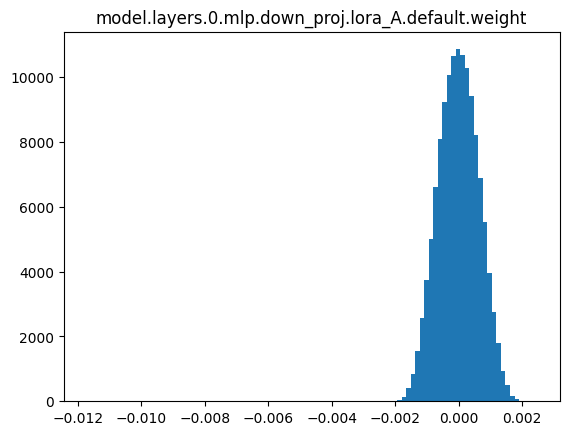

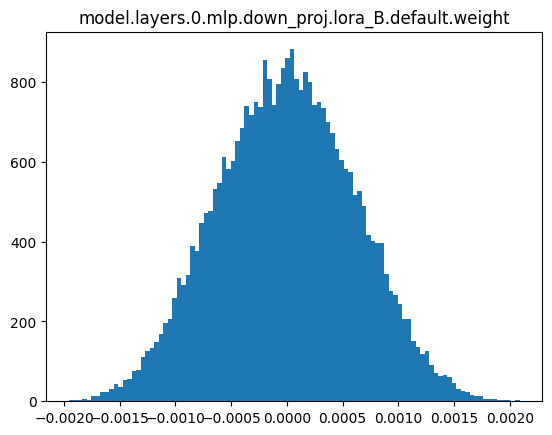

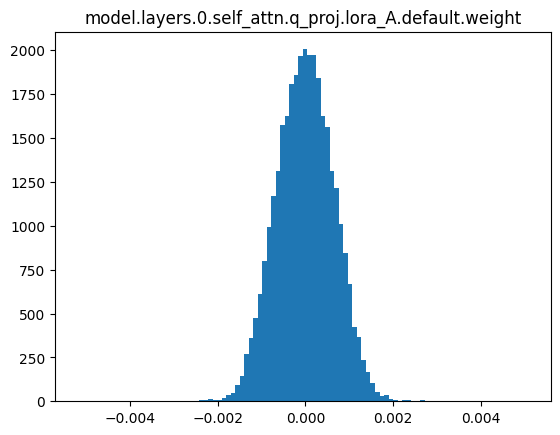

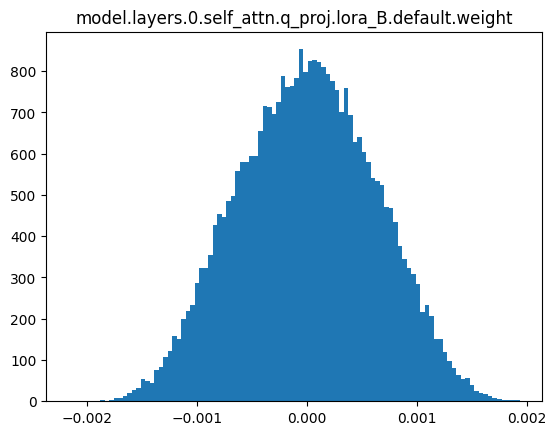

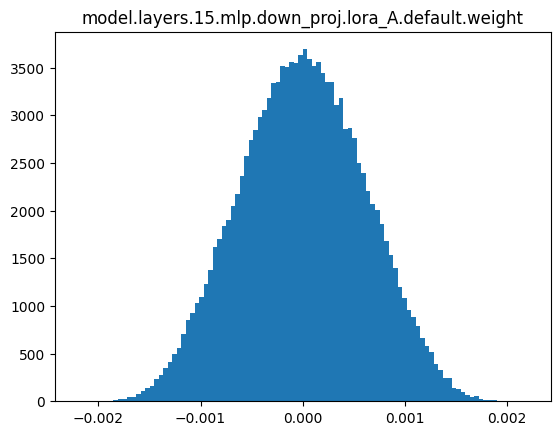

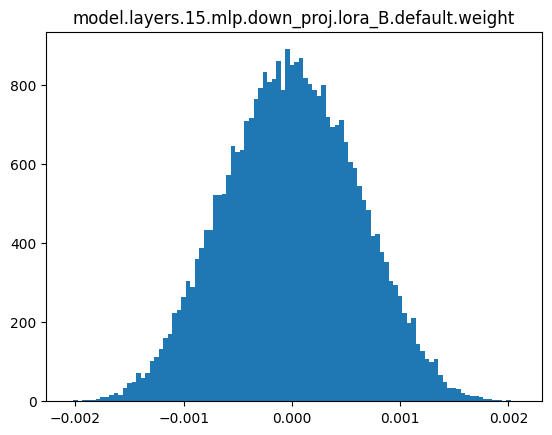

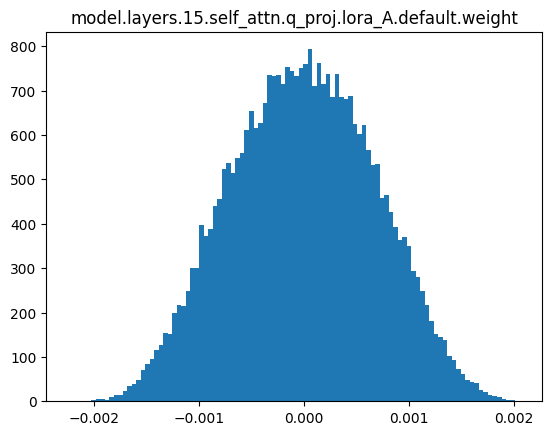

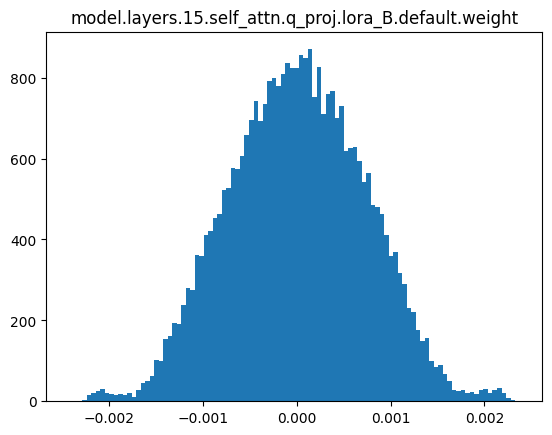

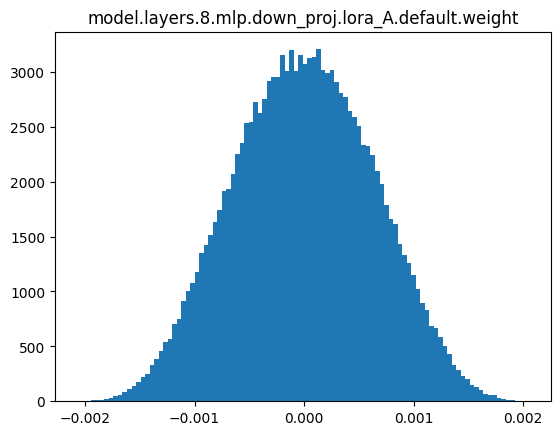

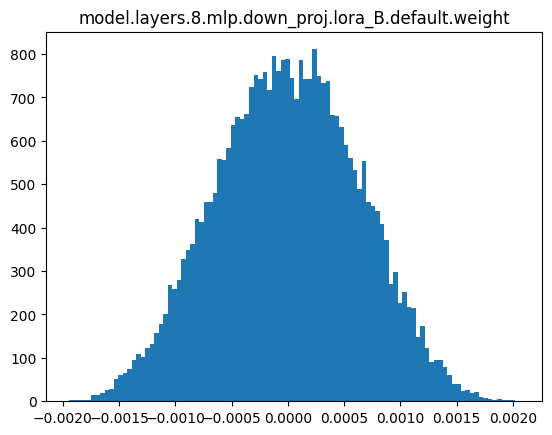

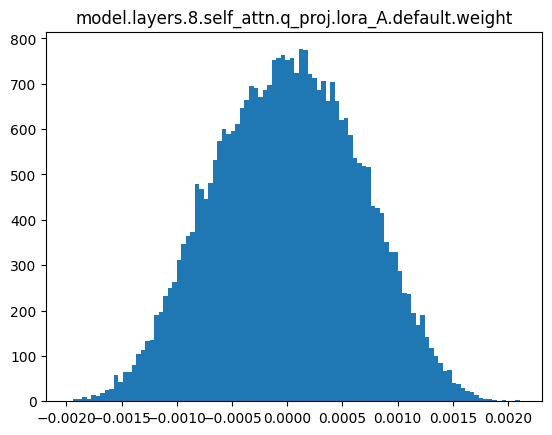

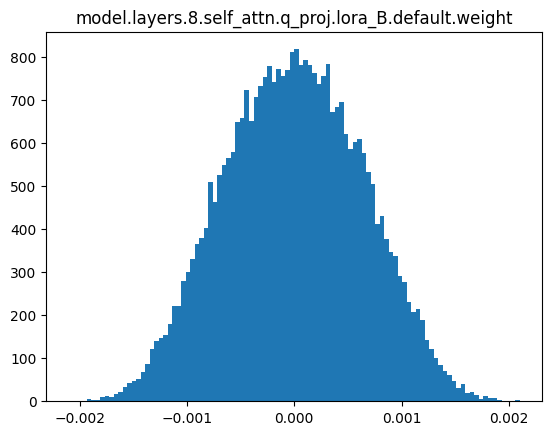

In [6]:
import matplotlib.pyplot as plt
import numpy as np

for i, (param, hist) in enumerate(zip(result.parameter_names, result.parameter_histograms)):
    plt.figure(i)
    plt.hist((np.array(hist.bin_edges[1:]) + np.array(hist.bin_edges[:-1])) / 2, weights=hist.bin_counts, bins=hist.bin_edges)
    plt.title(param)

## Activation Analysis

In [7]:
import json

stimfile = DATA_PATH / "stimuli.jsonl"
with open(stimfile, "r") as f:
    stimuli = [json.loads(line) for line in f]

print(stimuli)

[[{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'What should I do if I miss a dose of my medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Is it normal to feel tired all the time after starting a new medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'How can I lower my blood pressure naturally?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'When should I see a doctor for a persistent cough?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Are there side effects to getting the flu vaccine?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Can I take ibuprofen if I have stomach ulcers?'}], [{'role': 'system', 'content': 'You ar

In [8]:
with adapter.prepare_for_activation_capture(checkpoint_paths[-1], stimuli) as output:
    result = session.activation_analysis(
        project.id,
        checkpoint_paths[0],
        checkpoint_paths[1],
        [o[0]["generated_text"] for o in output],
        layer_names=[
            "model.layers.0.mlp.down_proj",
            "model.layers.0.self_attn.q_proj",
            "model.layers.8.mlp.down_proj",
            "model.layers.8.self_attn.q_proj",
            "model.layers.15.mlp.down_proj",
            "model.layers.15.self_attn.q_proj",
        ],
    )

Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0


In [9]:
print(result.to_dataframe())


                                  cosine_similarities  l2_distances
model.layers.0.mlp.down_proj                 1.000000      0.819353
model.layers.0.self_attn.q_proj              1.000000      2.794424
model.layers.15.mlp.down_proj                0.988281     73.414009
model.layers.15.self_attn.q_proj             0.996094     62.926292
model.layers.8.mlp.down_proj                 0.984375      7.486297
model.layers.8.self_attn.q_proj              1.000000     45.262772


## Correlation Analysis

In [10]:
import json

stimfile = DATA_PATH / "stimuli.jsonl"
with open(stimfile, "r") as f:
    stimuli = [json.loads(line) for line in f]

print(stimuli)

[[{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'What should I do if I miss a dose of my medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Is it normal to feel tired all the time after starting a new medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'How can I lower my blood pressure naturally?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'When should I see a doctor for a persistent cough?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Are there side effects to getting the flu vaccine?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Can I take ibuprofen if I have stomach ulcers?'}], [{'role': 'system', 'content': 'You ar

In [11]:
result = session.correlation_analysis(
    project.id,
    checkpoint_paths[1],
    stimuli,
    layer_names=[
        "model.layers.0.mlp.down_proj",
        "model.layers.0.self_attn.q_proj",
        "model.layers.8.mlp.down_proj",
        "model.layers.8.self_attn.q_proj",
        "model.layers.15.mlp.down_proj",
        "model.layers.15.self_attn.q_proj",
    ],
    reference_layer_name="model.norm",
)

Device set to use cuda:0


In [12]:
print(result.to_dataframe())

                                  correlation_scores
model.layers.0.mlp.down_proj                0.380173
model.layers.0.self_attn.q_proj             0.386541
model.layers.15.mlp.down_proj               0.381455
model.layers.15.self_attn.q_proj            0.381455
model.layers.8.mlp.down_proj                0.381455
model.layers.8.self_attn.q_proj             0.384006


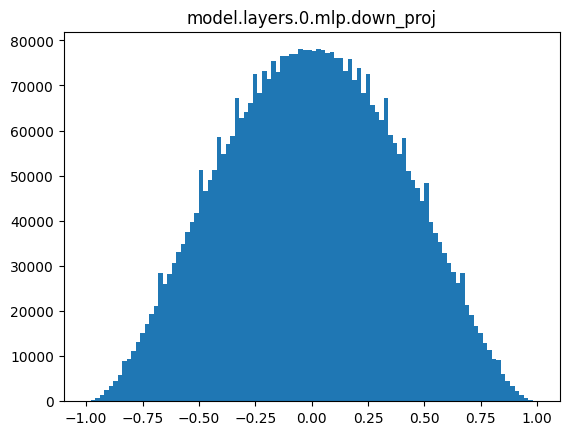

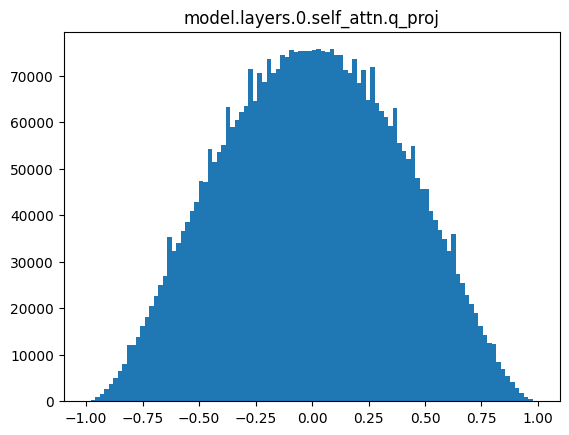

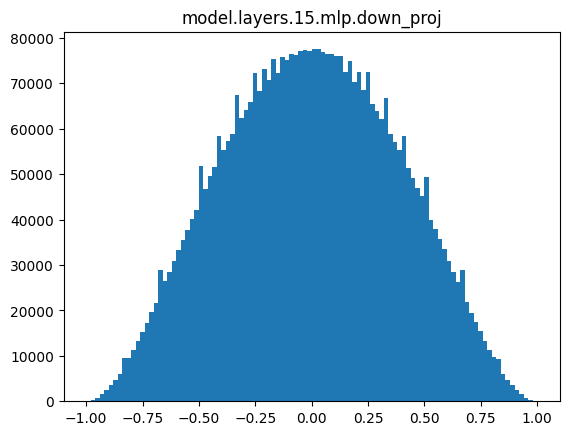

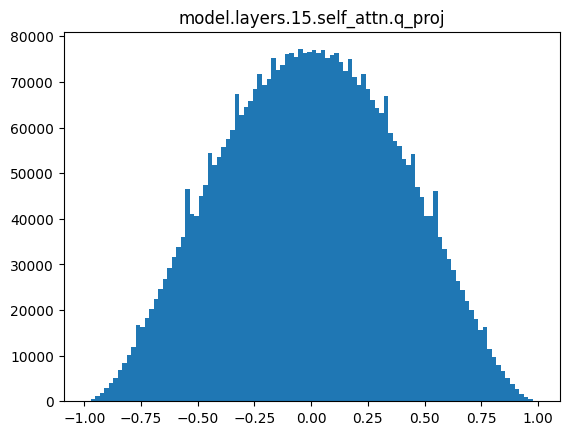

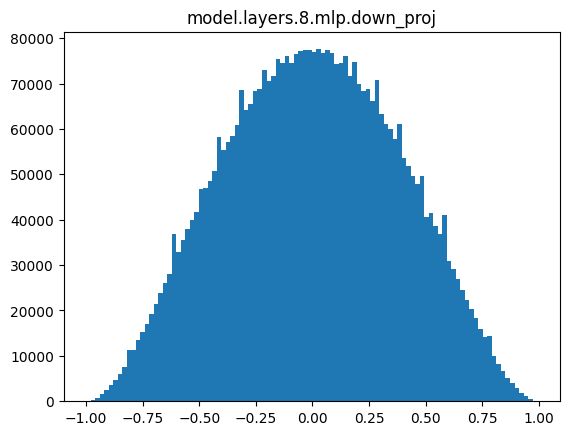

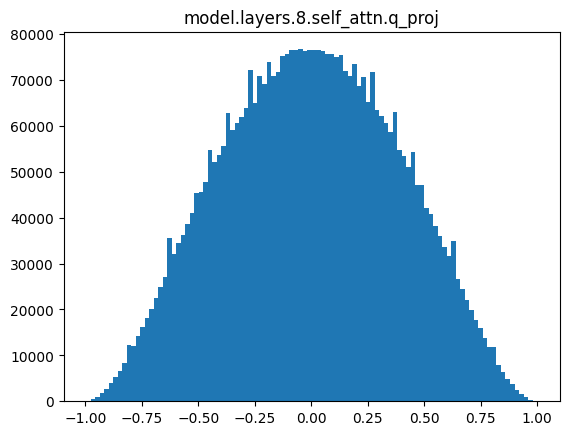

In [13]:
import matplotlib.pyplot as plt
import numpy as np

for i, (param, hist) in enumerate(zip(result.layer_names, result.correlation_histograms)):
    plt.figure(i)
    plt.hist((np.array(hist.bin_edges[1:]) + np.array(hist.bin_edges[:-1])) / 2, weights=hist.bin_counts, bins=hist.bin_edges)
    plt.title(param)

## Exclude Training

In [14]:
session.exclude_training(
    project.id,
    checkpoint_paths,
    [2],
    DATA_PATH / "excluded_2",
)

Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0


data/HF_MedicalChatbot/excluded_2

In [15]:
(DATA_PATH / "excluded_2").is_dir()

True

## Zero-Training Optimization & Maintenance (ZTOM)

In [16]:
from sentence_transformers import SentenceTransformer

def sentence_similarity_loss_fn(
    expected_output: list[str],
    output: list[list[dict[str, str]]],
) -> float:
    similarity_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    generated_embeddings = similarity_model.encode(
        [o[0]["generated_text"][-1]["content"] for o in output]
    )
    expected_embeddings = similarity_model.encode(expected_output)
    score = (
        similarity_model.similarity_pairwise(generated_embeddings, expected_embeddings)
        .mean()
        .item()
    )
    return score

In [17]:
import json

stimfile = DATA_PATH / "stimuli.jsonl"
with open(stimfile, "r") as f:
    stimuli = [json.loads(line) for line in f]

print(stimuli)

[[{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'What should I do if I miss a dose of my medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Is it normal to feel tired all the time after starting a new medication?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'How can I lower my blood pressure naturally?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'When should I see a doctor for a persistent cough?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Are there side effects to getting the flu vaccine?'}], [{'role': 'system', 'content': 'You are a helpful medical professional'}, {'role': 'user', 'content': 'Can I take ibuprofen if I have stomach ulcers?'}], [{'role': 'system', 'content': 'You ar

In [18]:
with open(DATA_PATH / "expected_outputs.txt", "r") as f:
    expected_output = [line.strip() for line in f]

expected_output

['If you miss a dose, you should take the missed dose as soon as possible. You should not wait until the next scheduled dose. If you are missing doses regularly, your doctor will tell you to take them regularly. If you have missed one dose, you should take another one as soon as possible. You should not take any extra dose.',
 'I went through your query and can understand your concern.  Yes, it is normal to feel tired all the time after starting a new medication. The new medication can cause fatigue, which is a common side effect of many drugs. This fatigue is usually temporary and resolves on its own within a few days. If you are still feeling tired, it is best to consult your doctor and discuss with them about your medication. They can help you identify the cause of your fatigue and suggest the appropriate treatment. In',
 'I can understand your concern.  There are many ways to lower blood pressure naturally. Here are some of the ways:  1. Exercise regularly. Regular exercise can hel

In [19]:
from authentrics import ZtomOptimizationOptions

# Optional: tune optimization (defaults are often sufficient)
# In this case, we want to maximize the similarity between the generated and expected outputs.
options = ZtomOptimizationOptions(minimize=False)

# loss_function: callable(model_output) -> float
# can be passed directly as a lambda or normal function
result = session.ztom_analysis(
    project.id,
    checkpoint_paths,
    stimuli,
    loss_function=lambda y_pred: sentence_similarity_loss_fn(expected_output, y_pred),
    new_checkpoint_path=DATA_PATH / "checkpoint_optimized",
    optimization_options=options,
)

Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [20]:
print(result.scaling_factors)
print(result.number_of_inferences)

[1.047224268004764, -0.020599906484754963, -0.1137778765384947]
34
